In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Analysis

## Read in dataset

In [ ]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', low_memory=False)
print(f'Shape: {df.shape}')
df.head()

## Peruse column names / types

In [152]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 153 columns):
 #    Column                                      Dtype         
---   ------                                      -----         
 0    id                                          object        
 1    member_id                                   float64       
 2    loan_amnt                                   float64       
 3    funded_amnt                                 float64       
 4    funded_amnt_inv                             float64       
 5    term                                        object        
 6    int_rate                                    float64       
 7    installment                                 float64       
 8    grade                                       object        
 9    sub_grade                                   object        
 10   emp_title                                   object        
 11   emp_length                         

## Null Percentages

Here we take a look at which columns have high representation of null values

In [153]:
null_percentage = round((df.isnull().sum() / len(df)) * 100, 2)
null_percentage = null_percentage.sort_values(ascending=True)

print("Percentage of Nulls per Column:\n")
print(null_percentage.to_string())

Percentage of Nulls per Column:

id                                              0.00
pub_rec                                         0.00
revol_bal                                       0.00
total_acc                                       0.00
initial_list_status                             0.00
out_prncp                                       0.00
out_prncp_inv                                   0.00
total_pymnt                                     0.00
total_pymnt_inv                                 0.00
total_rec_prncp                                 0.00
total_rec_int                                   0.00
total_rec_late_fee                              0.00
recoveries                                      0.00
collection_recovery_fee                         0.00
last_pymnt_amnt                                 0.00
last_credit_pull_d                              0.00
last_fico_range_high                            0.00
last_fico_range_low                             0.00
policy_code  

In [154]:
total_columns = len(null_percentage)
no_null_cols = (null_percentage == 0).sum()
low_null_cols = ((null_percentage > 0) & (null_percentage < 14)).sum()
high_null_cols = (null_percentage >= 14).sum()

print(f"no nulls (0%):          {no_null_cols}/{total_columns} ({round(no_null_cols / total_columns * 100, 2)}%)")
print(f"low nulls (<14%):       {low_null_cols}/{total_columns} ({round(low_null_cols / total_columns * 100, 2)}%)")
print(f"high nulls (14%+):      {high_null_cols}/{total_columns} ({round(high_null_cols / total_columns * 100, 2)}%)")

no nulls (0%):          51/153 (33.33%)
low nulls (<14%):       44/153 (28.76%)
high nulls (14%+):      58/153 (37.91%)


## Notes so far

- Significant string(object) type columns that will likely need some cleaning/trimming.
- Roughly a third of the columns have no missing values
- Roughly a third of the columns have low levels of missing values
- Roughly a third of the columns have significantly high levels of missing values

### At least initially, I lean towards excluding/dropping these columns from analysis unless I can verify that being `null` is ever informative.


## Lets take a glance at columns with high null counts

- `next_payment_d` at a glance looks like it could be a column that is null when loans are closed.

In [155]:
high_null_columns = null_percentage[null_percentage >= 14].index.tolist()
df[high_null_columns].sample(10)

,total_cu_tl,inq_last_12m,inq_fi,max_bal_bc,open_rv_24m,open_rv_12m,open_acc_6m,total_bal_il,open_act_il,open_il_24m,...,payment_plan_start_date,hardship_end_date,hardship_start_date,deferral_term,hardship_status,hardship_reason,hardship_type,hardship_amount,orig_projected_additional_accrued_interest,member_id
1095883,1.0,3.0,3.0,14112.0,0.0,0.0,0.0,38772.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1428058,1.0,0.0,2.0,4990.0,2.0,0.0,0.0,14862.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
292303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1580663,19.0,2.0,0.0,11394.0,5.0,3.0,2.0,66205.0,6.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1595219,0.0,0.0,0.0,5009.0,5.0,2.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
851183,1.0,0.0,0.0,2267.0,2.0,0.0,0.0,43780.0,2.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
529829,5.0,2.0,2.0,3150.0,5.0,2.0,2.0,152736.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
969014,2.0,2.0,1.0,4092.0,6.0,2.0,2.0,25625.0,3.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1179433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1846499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## As expected, there is some correlation between `loan_status` and nullability on some of these columns, but it's never 1 to 1.

- date columns are likely to be null unless it's something very likely to be known at loan inception, like `issue_date`
- numerical columns could be imputed with zeros, which we will check next

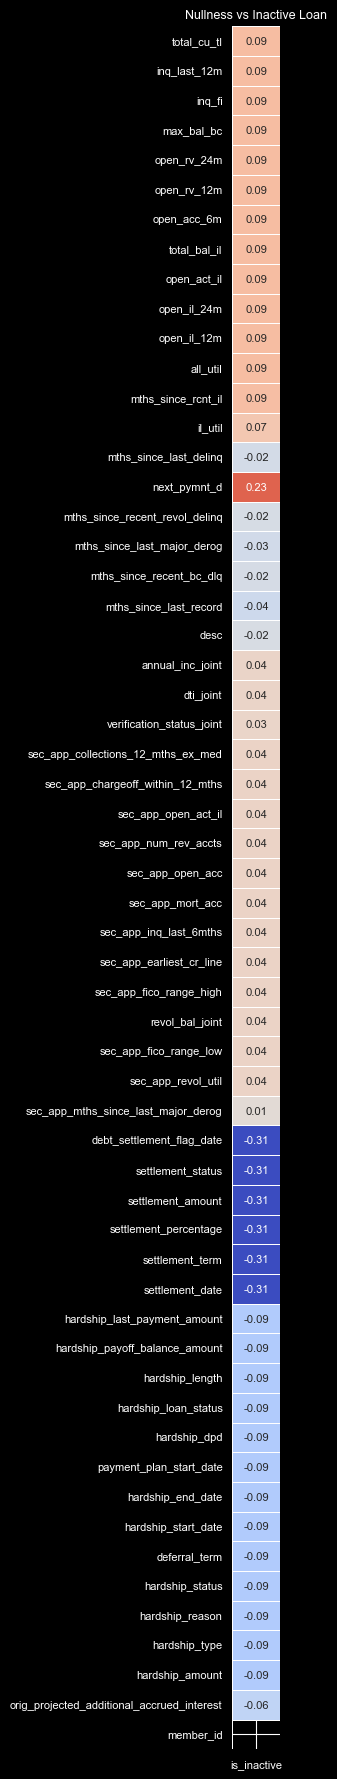

In [156]:
inactive_statuses = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'In Grace Period',
    'Does not meet the credit policy. Status:Charged Off'
]

# Create binary columns: is_inactive and is_null for each high null column
df['is_inactive'] = df['loan_status'].isin(inactive_statuses).astype(int)

null_flags = pd.DataFrame({col: df[col].isnull().astype(int) for col in high_null_columns})
null_flags['is_inactive'] = df['is_inactive']

corr_matrix = null_flags.corr()[['is_inactive']].drop('is_inactive')

plt.figure(figsize=(3, len(high_null_columns) * 0.3 + 0.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, annot_kws={"size": 8}, cbar=False)
plt.title("Nullness vs Inactive Loan", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

## Let's take a look at how the data in each numerical column looks after imputing `0` over `null`

At a glance:
- likely skewing data as opposed to making it useful.
- some few columns, like `all_util` show some normality for the data that is there. This could be worth looking into later.

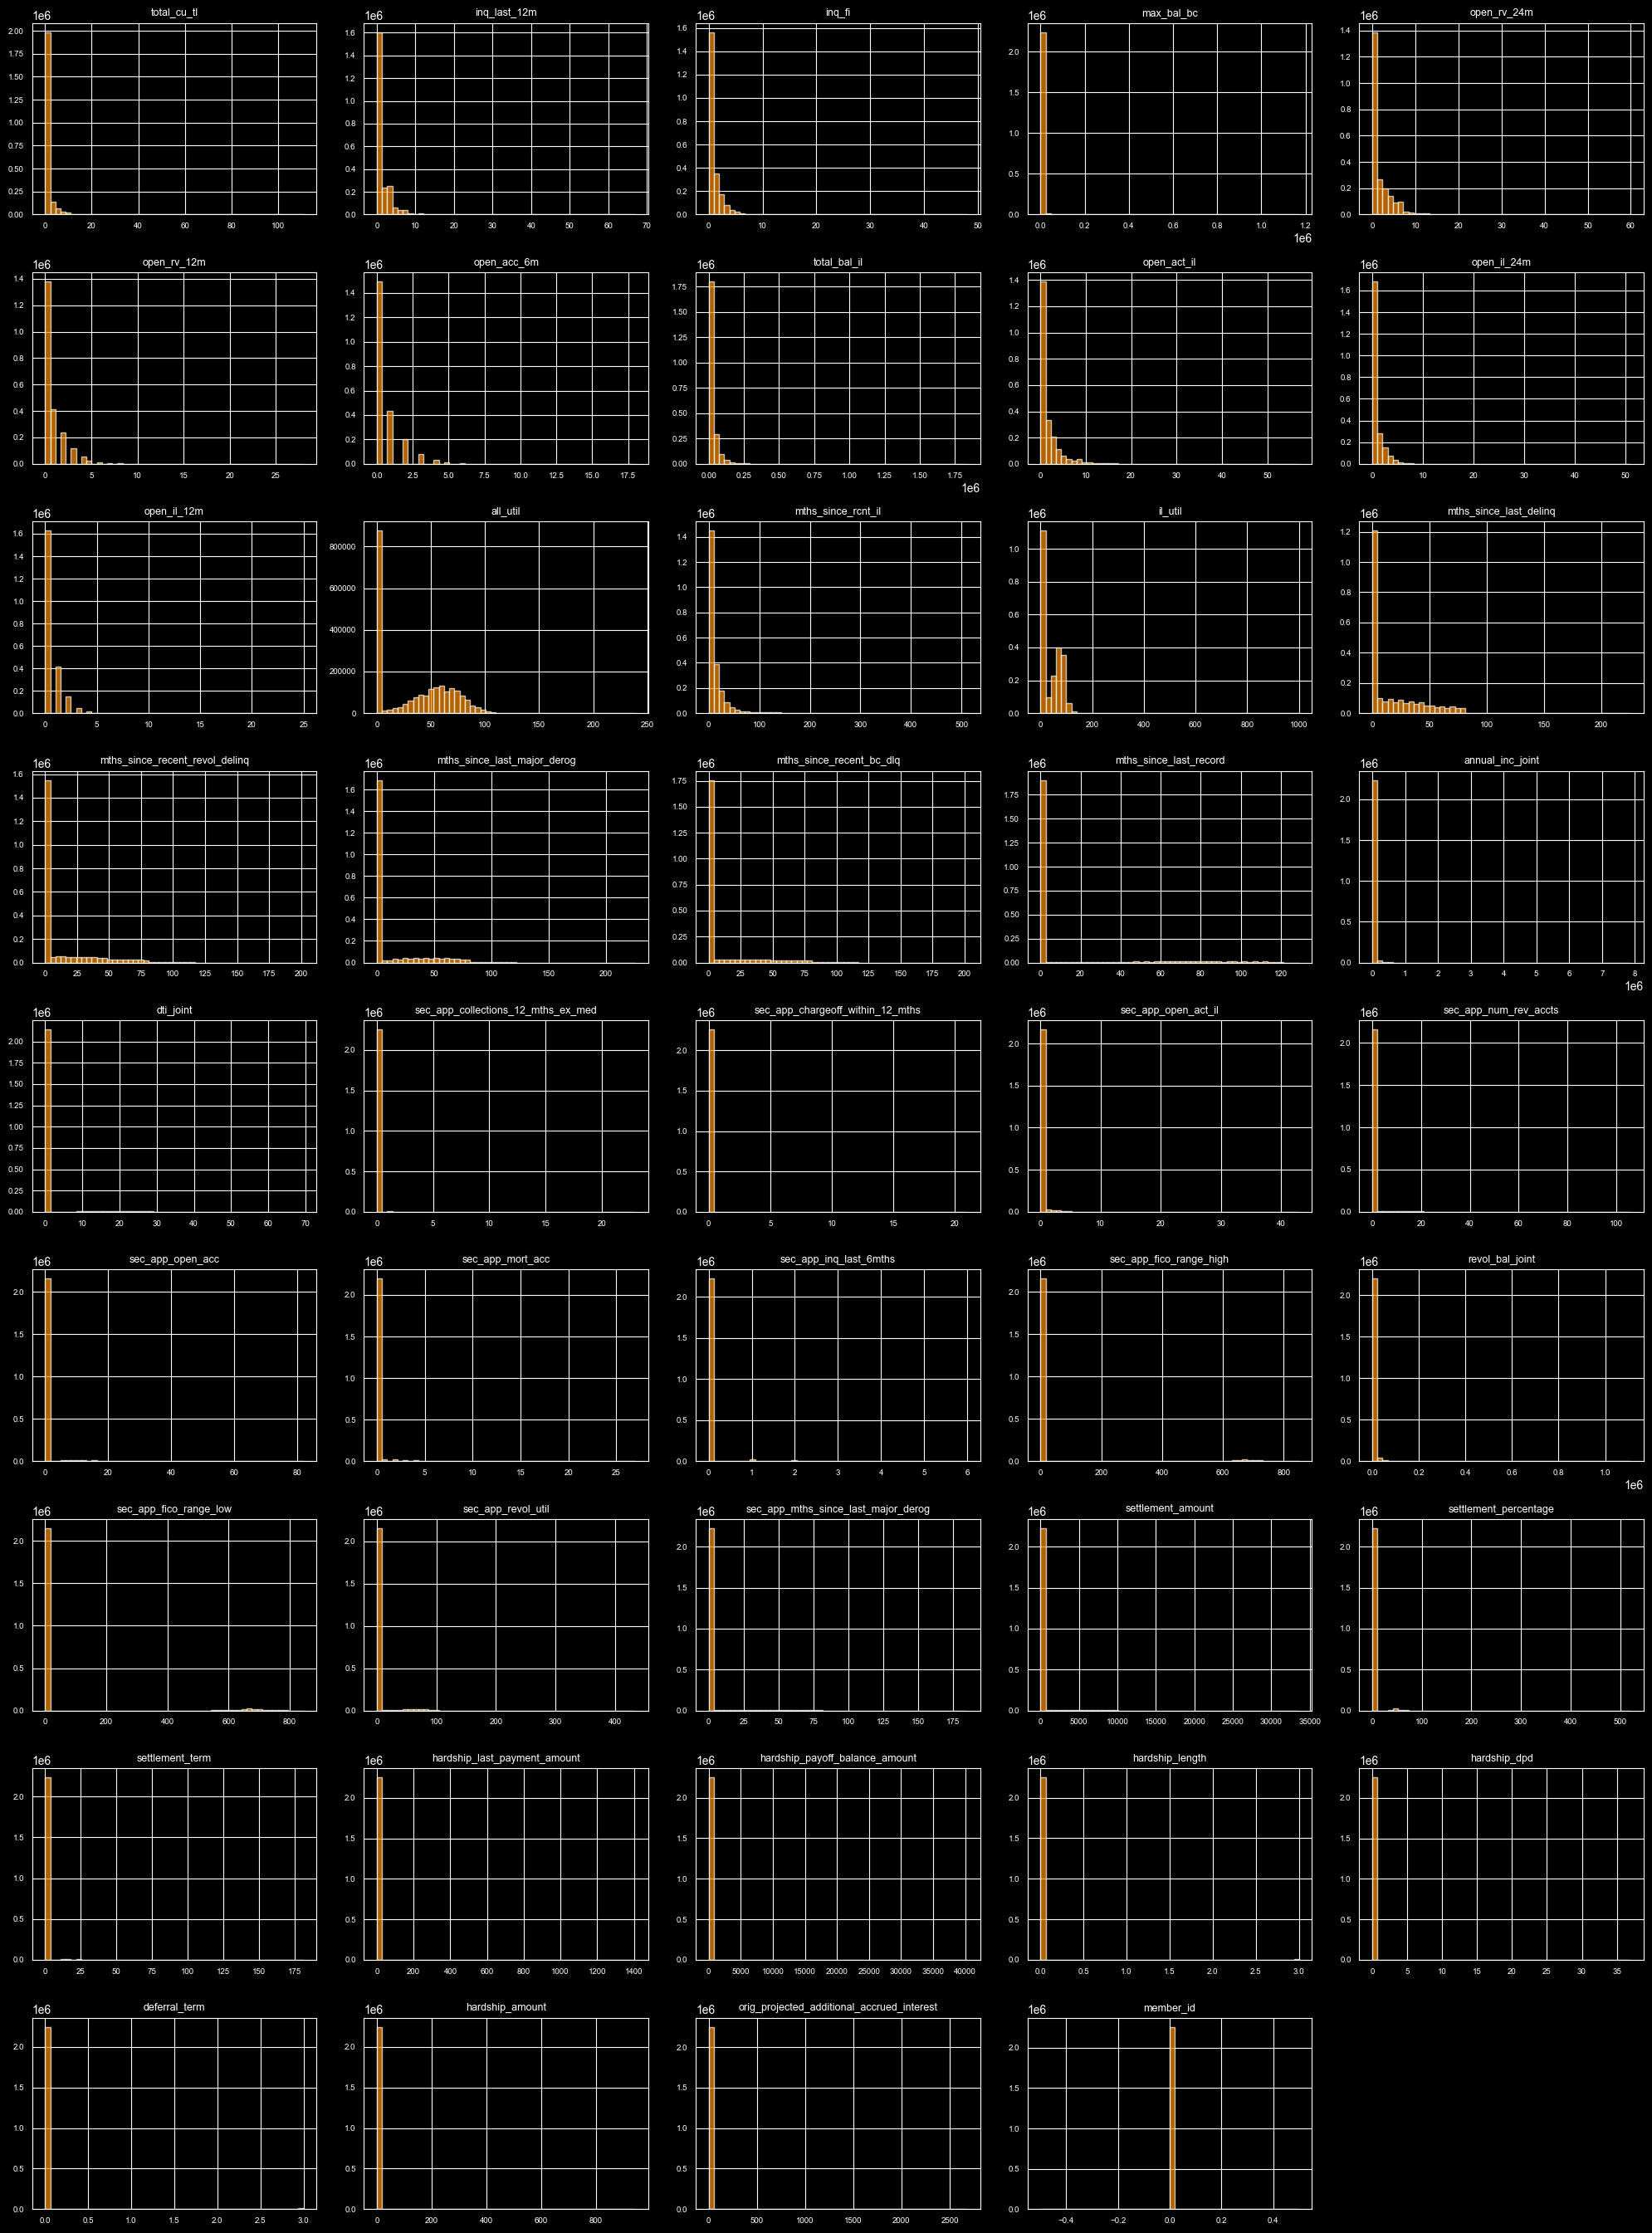

In [157]:
import math
float_cols = df[high_null_columns].select_dtypes(include='float64').columns.tolist()

# Impute zeros
df_after = df.copy()
df_after[float_cols] = df_after[float_cols].fillna(0)

n_cols = 5
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    df_after[col].hist(ax=axes[i], bins=50, color='darkorange', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(len(float_cols), len(axes)):
    axes[j].set_visible(False)

plt.title("Float Columns After Zero Imputation", fontsize=12)
plt.tight_layout()
plt.show()

## For now we have enough to exclude the columns with high null counts from the data set for our anlysic going forwards.

In [158]:
df_pruned = df[df.columns[~df.columns.isin(high_null_columns)]].copy()
df_pruned

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,is_inactive,issue_d_dt
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,2015-12-01
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,2015-12-01
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,2015-12-01
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,...,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N,0,2015-12-01
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0,2015-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,...,0.0,55970.0,28398.0,12300.0,42670.0,N,Cash,N,0,2016-10-01
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,...,0.0,84664.0,62426.0,20700.0,58764.0,N,Cash,Y,1,2016-10-01
2260698,88215728,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,Customer Service Technician,...,0.0,163804.0,44215.0,9500.0,34169.0,N,Cash,N,0,2016-10-01
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT


## With our new pruned dateset, we impute `0` for nulls on numerical columns and check to see if it breaks normality significantly for any of the columns

- we also get a high level view and see if any graphs look skewed

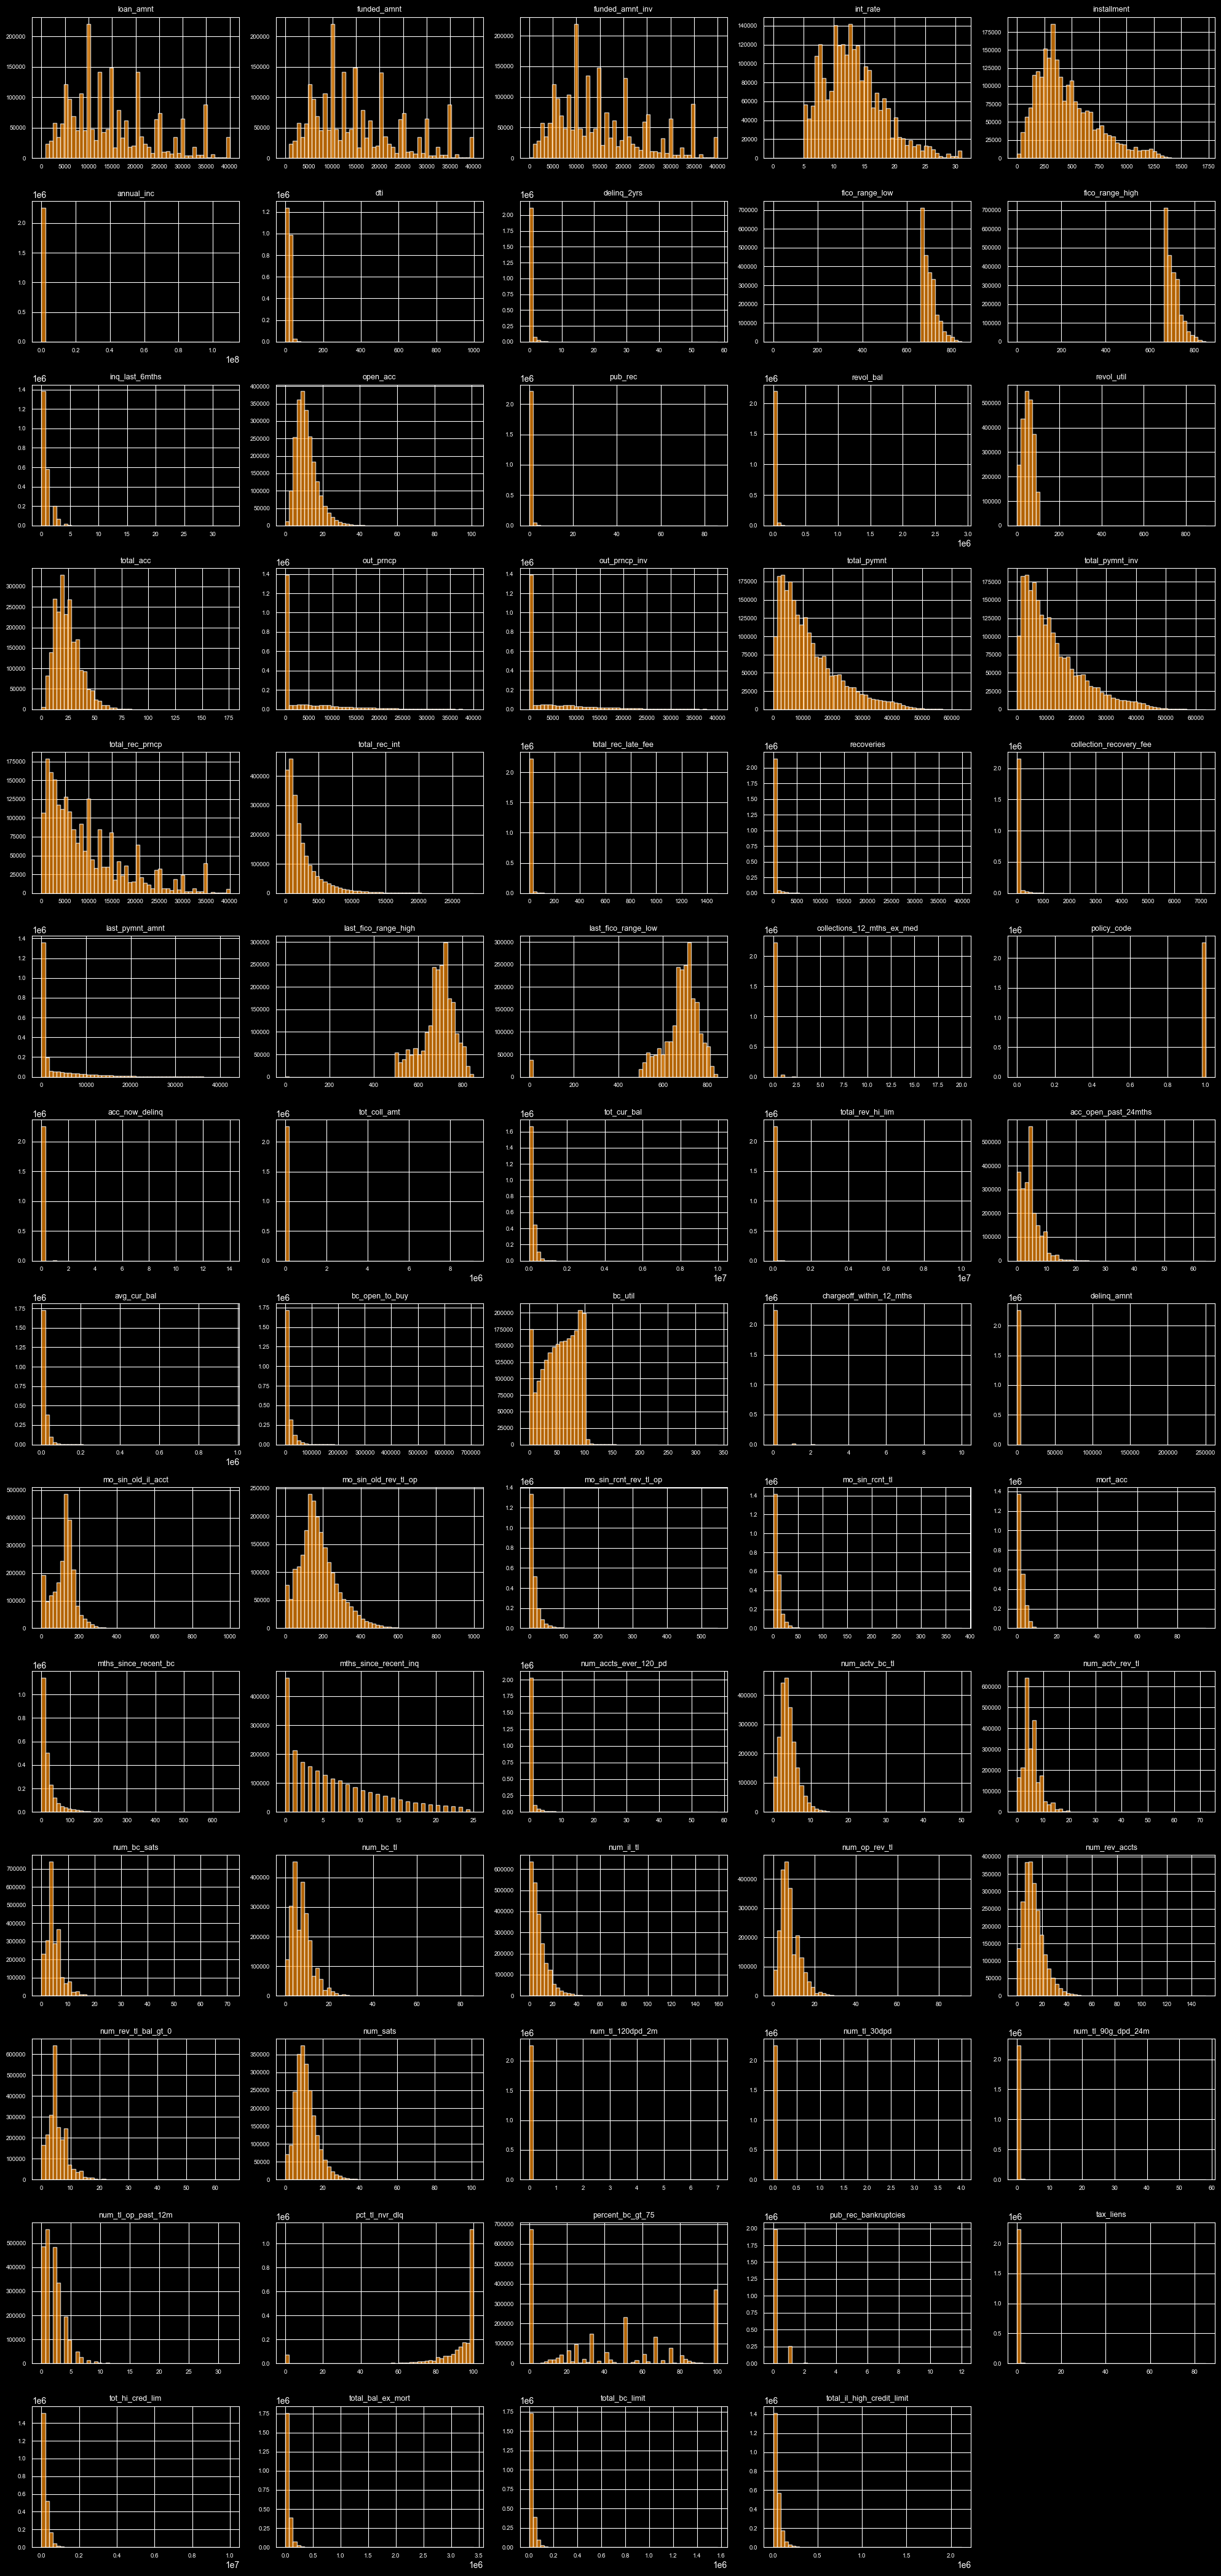

In [159]:
float_cols = df_pruned.select_dtypes(include='float64').columns.tolist()

# Impute zeros
df_after = df_pruned.copy()
df_after[float_cols] = df_after[float_cols].fillna(0)

n_cols = 5
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    df_after[col].hist(ax=axes[i], bins=50, color='darkorange', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(len(float_cols), len(axes)):
    axes[j].set_visible(False)

plt.title("Float Columns After Zero Imputation", fontsize=12)
plt.tight_layout()
plt.show()

## Looking at some of these distributions, the scales of `annual_inc` and `avg_cur_bal` appear to be being skewed by outlier highs in the data.

- there are more columns with similar behavior, appear to be correlated with income
- likely high earners pulling the upper tail across multiple variables simultaneously
- we trim the outliers out using built-in pandas quartile-based filtering

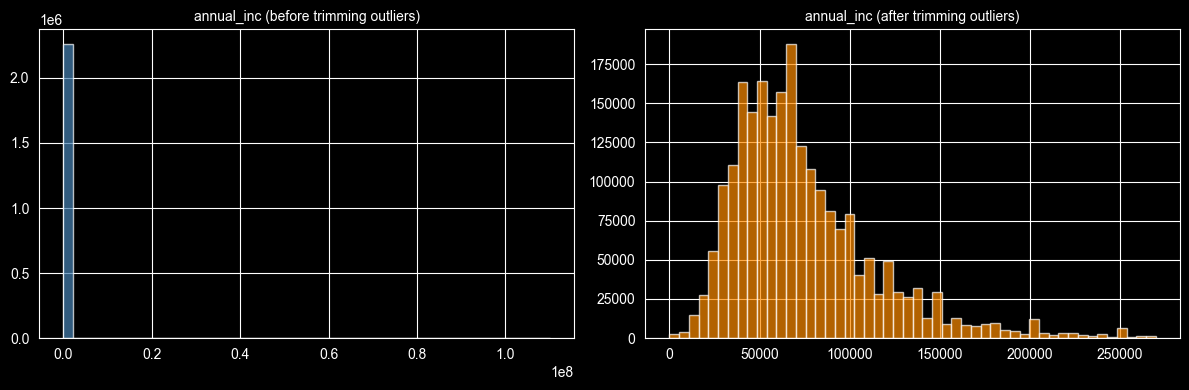

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
df_pruned['annual_inc'].hist(ax=axes[0], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('annual_inc (before trimming outliers)', fontsize=10)

# Trim outliers
q99 = df_pruned['annual_inc'].quantile(0.99)
df_pruned = df_pruned[df_pruned['annual_inc'] <= q99]

# After
df_pruned['annual_inc'].hist(ax=axes[1], bins=50, color='darkorange', alpha=0.7)
axes[1].set_title('annual_inc (after trimming outliers)', fontsize=10)

plt.tight_layout()
plt.show()

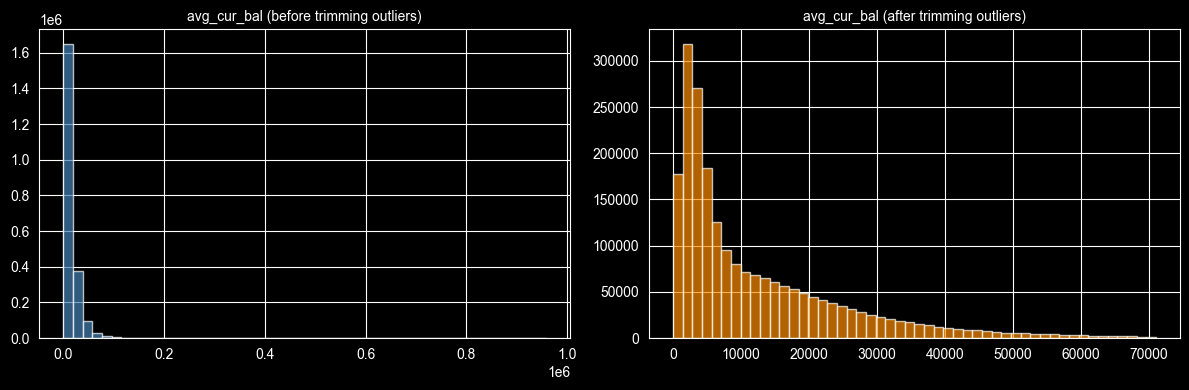

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
df_pruned['avg_cur_bal'].hist(ax=axes[0], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('avg_cur_bal (before trimming outliers)', fontsize=10)

# Trim outliers
q99 = df_pruned['avg_cur_bal'].quantile(0.99)
df_pruned = df_pruned[df_pruned['avg_cur_bal'] <= q99]

# After
df_pruned['avg_cur_bal'].hist(ax=axes[1], bins=50, color='darkorange', alpha=0.7)
axes[1].set_title('avg_cur_bal (after trimming outliers)', fontsize=10)

plt.tight_layout()
plt.show()

## The `term` column is currently an `object(string)` type.

- Even though it's basically a categorical value, we'll parse it into an `int` for use-ablity.

In [162]:
df_pruned.groupby('term')['id'].count()

term
36 months    1525343
60 months     621208
Name: id, dtype: int64

In [163]:
df_pruned['term_as_int'] = df_pruned['term'].str.strip().str.replace('months', '').astype(float)

In [164]:
df_pruned.groupby('term_as_int')['id'].count()

term_as_int
36.0    1525343
60.0     621208
Name: id, dtype: int64

## Tracking Default Rate Over Time (Resolved Loans Only)

- We will be tracking `default_rate` over time, grouped by loan issue date.
- `default_rate` = (number of defaulted loans / total resolved loans) × 100
- because `issue_d` is an object(string) we parse it into a `datetime` and call it `issue_d_dt` to make our `groupby` cleaner.
- We will calculate and plot this rate for all loans combined, as well as separately for 36-month and 60-month loan terms.

In [165]:
default_statuses = {'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'}

resolved_statuses = {
    # 'Current',
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
}

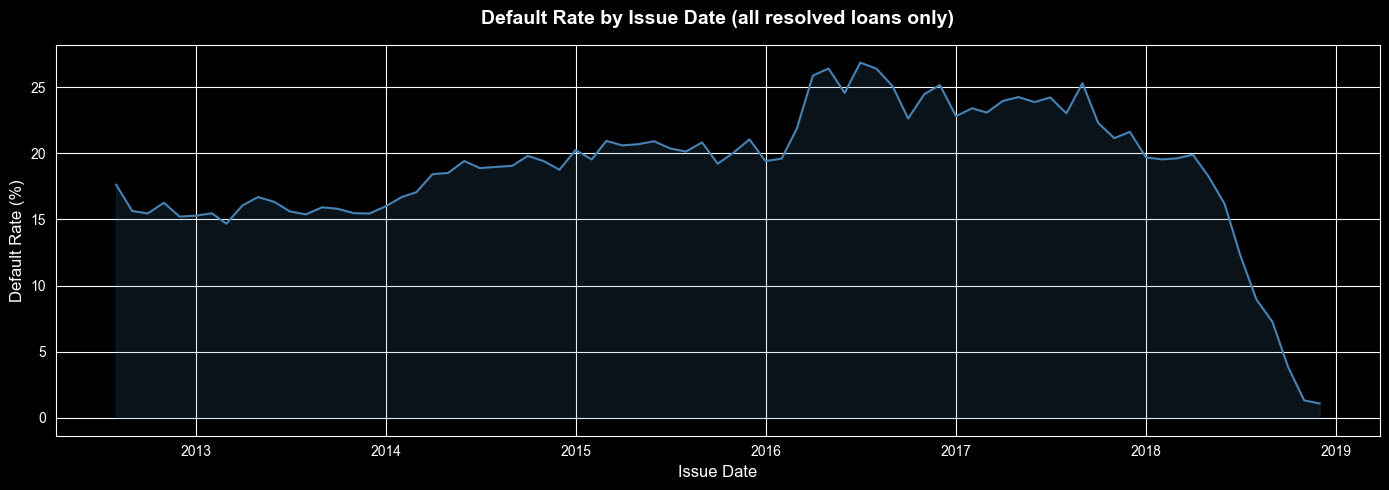

In [191]:
df_resolved = df_pruned[df_pruned['loan_status'].isin(resolved_statuses)].copy()

df_resolved['issue_d_dt'] = pd.to_datetime(df_resolved['issue_d'], format='%b-%Y', errors='coerce')
df_resolved['is_default'] = df_resolved['loan_status'].isin(default_statuses).astype(int)


default_by_date = (
    df_resolved
    .groupby('issue_d_dt')['is_default']
    .agg(default_rate=lambda x: x.mean() * 100, count='count')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(default_by_date.index, default_by_date['default_rate'], color='steelblue', linewidth=1.5)
ax.fill_between(default_by_date.index, default_by_date['default_rate'], alpha=0.15, color='steelblue')

ax.set_title('Default Rate by Issue Date (all resolved loans only)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Issue Date', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()

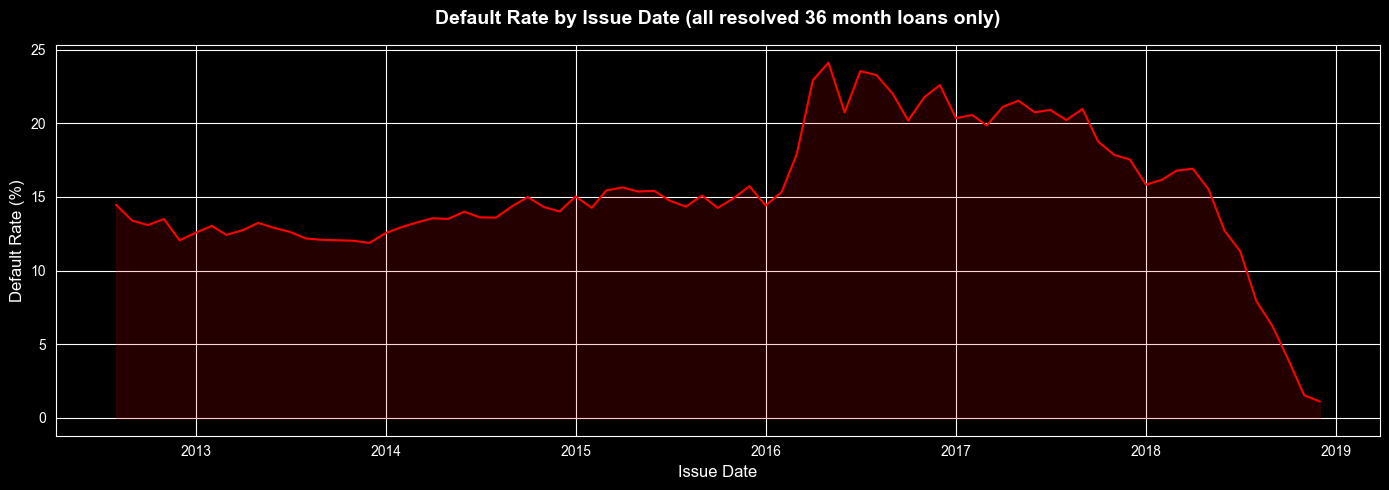

In [167]:
df_pruned_36_month_loans = df_pruned[df_pruned['term_as_int'] == 36]
df_resolved = df_pruned_36_month_loans[df_pruned_36_month_loans['loan_status'].isin(resolved_statuses)].copy()

df_resolved['issue_d_dt'] = pd.to_datetime(df_resolved['issue_d'], format='%b-%Y', errors='coerce')
df_resolved['is_default'] = df_resolved['loan_status'].isin(default_statuses).astype(int)


default_by_date = (
    df_resolved
    .groupby('issue_d_dt')['is_default']
    .agg(default_rate=lambda x: x.mean() * 100, count='count')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(default_by_date.index, default_by_date['default_rate'], color='red', linewidth=1.5)
ax.fill_between(default_by_date.index, default_by_date['default_rate'], alpha=0.15, color='red')

ax.set_title('Default Rate by Issue Date (all resolved 36 month loans only)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Issue Date', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()

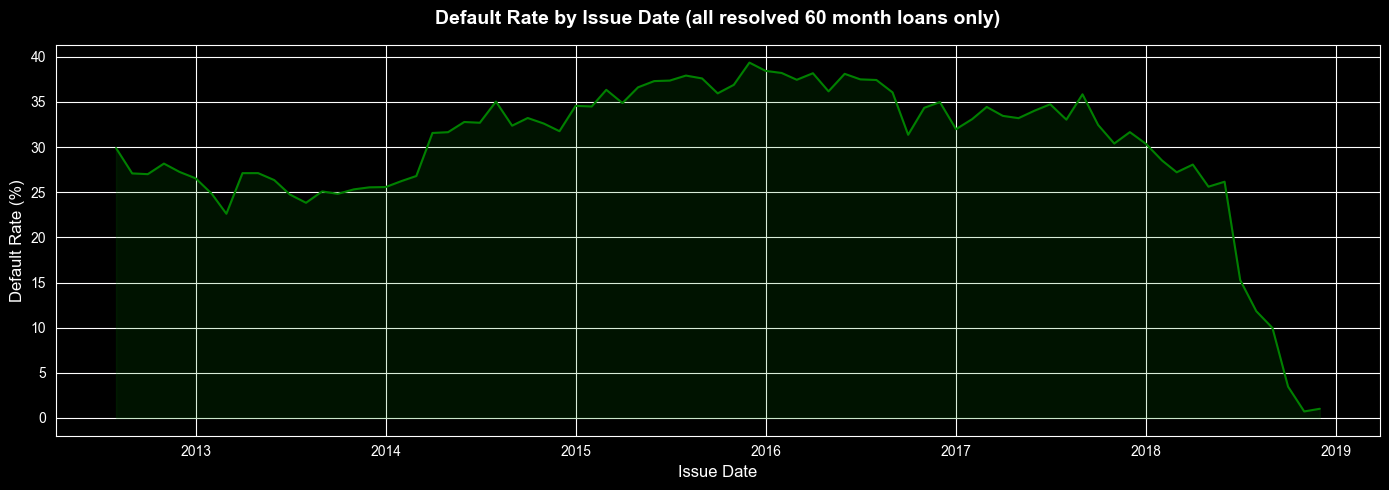

In [168]:
df_pruned['term_as_int'] = df_pruned['term'].str.strip().str.replace(' months', '').astype(float)
df_pruned_60_month_loans = df_pruned[df_pruned['term_as_int'] == 60]
df_resolved = df_pruned_60_month_loans[df_pruned_60_month_loans['loan_status'].isin(resolved_statuses)].copy()

df_resolved['issue_d_dt'] = pd.to_datetime(df_resolved['issue_d'], format='%b-%Y', errors='coerce')
df_resolved['is_default'] = df_resolved['loan_status'].isin(default_statuses).astype(int)


default_by_date = (
    df_resolved
    .groupby('issue_d_dt')['is_default']
    .agg(default_rate=lambda x: x.mean() * 100, count='count')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(default_by_date.index, default_by_date['default_rate'], color='green', linewidth=1.5)
ax.fill_between(default_by_date.index, default_by_date['default_rate'], alpha=0.15, color='green')

ax.set_title('Default Rate by Issue Date (all resolved 60 month loans only)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Issue Date', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()

## For sanity, some sniff checks

- spike in 2016 coincides with spike in defaults for 36-month loans issued at that time
- our assumptions of the data are also tested by checking the minimum issue date for 36-month and 60-month loans.

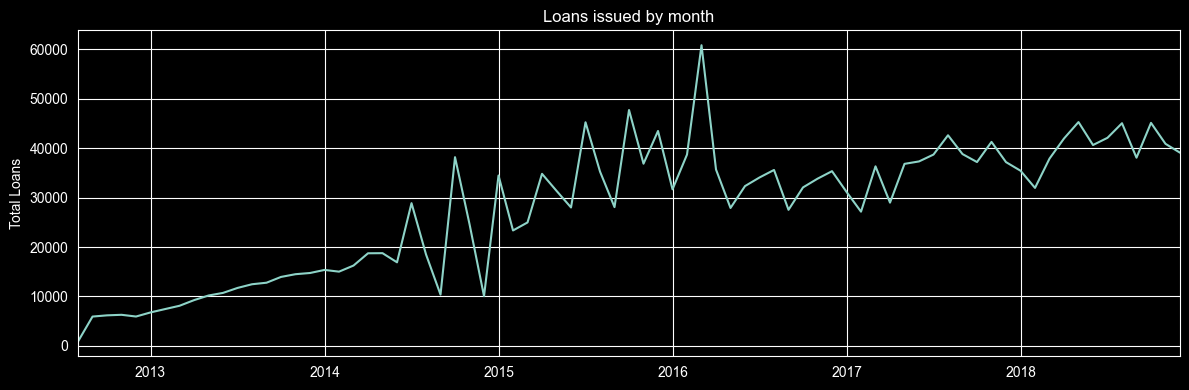

In [169]:
df_pruned['issue_d_dt'] = pd.to_datetime(df_pruned['issue_d'], format='%b-%Y', errors='coerce')
monthly = df_pruned.groupby('issue_d_dt').id.count()  # millions

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title('Loans issued by month')
ax.set_ylabel('Total Loans')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [170]:
df_pruned[(df_pruned['loan_status'] == 'Current') & (df_pruned['term_as_int'] == 36)].issue_d.min(), df_pruned[(df_pruned['loan_status'] == 'Current') & (df_pruned['term_as_int'] == 60)].issue_d.min()

('Apr-2016', 'Apr-2014')

# Appendix

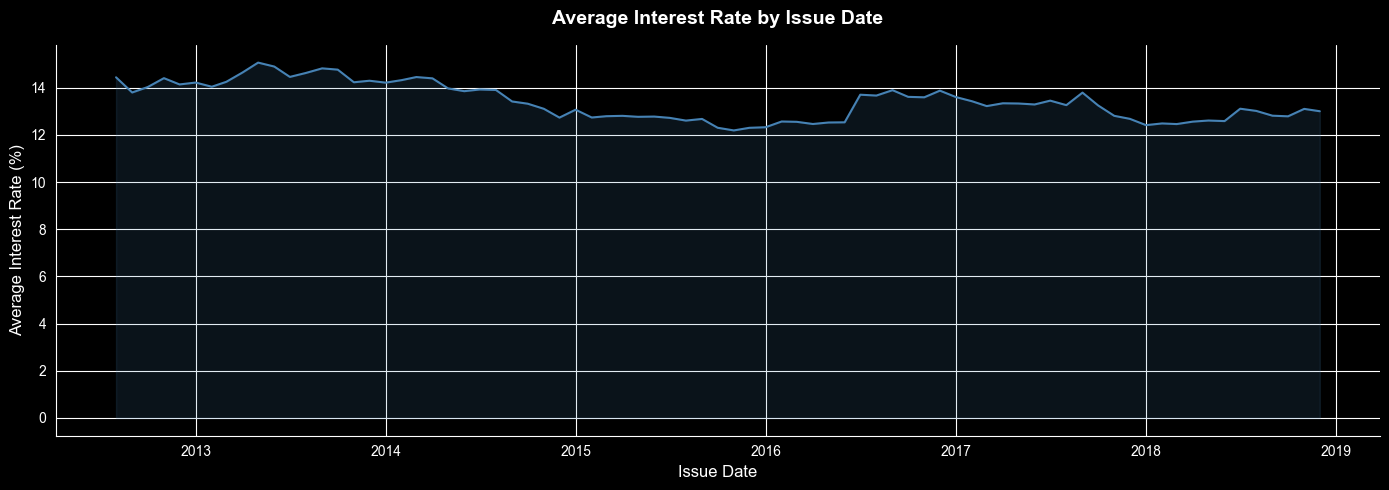

In [182]:
avg_rate_by_month = df_pruned[df_pruned['term_as_int'] > 0].groupby('issue_d_dt')['int_rate'].mean().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_rate_by_month.index, avg_rate_by_month.values, color='steelblue', linewidth=1.5)
ax.fill_between(avg_rate_by_month.index, avg_rate_by_month.values, alpha=0.15, color='steelblue')

ax.set_title('Average Interest Rate by Issue Date', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Issue Date', fontsize=12)
ax.set_ylabel('Average Interest Rate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
status_counts = df['loan_status'].value_counts()
print(status_counts.to_string())

In [ ]:
grade_counts = df['grade'].value_counts()
print(grade_counts.to_string())

In [ ]:
grade_counts = df['grade'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Grade Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Grade', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

## Default Rate by Home Ownership

In [ ]:
default_statuses = {'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'}

df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)

# Focus on meaningful ownership categories (exclude rare/other)
ownership_order = ['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'NONE', 'ANY']
default_by_ownership = (
    df[df['home_ownership'].isin(ownership_order)]
    .groupby('home_ownership')['is_default']
    .agg(default_rate=lambda x: x.mean() * 100, count='count')
    .reindex(ownership_order)
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    default_by_ownership.index,
    default_by_ownership['default_rate'],
    color='steelblue', edgecolor='white', linewidth=0.8
)

for bar, (_, row) in zip(bars, default_by_ownership.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{row['default_rate']:.1f}%\n(n={int(row['count']):,})",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Home Ownership', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, default_by_ownership['default_rate'].max() * 1.25)

plt.tight_layout()
plt.show()

In [ ]:
df.home_ownership.unique()

In [ ]:
df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
monthly = df.groupby('issue_d_dt')['loan_amnt'].sum()  # millions

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title('Monthly Loan Volume Issued')
ax.set_ylabel('Total Loan Amount ($ millions)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Default Rate by Employment Length

In [ ]:
num_cols = df_closed.select_dtypes(include='number').columns.tolist()
# Drop columns with >50% missing
num_cols = [c for c in num_cols if df_closed[c].isnull().mean() < 0.5]
corr = df_closed[num_cols].corr()[['default']].sort_values('default', ascending=False)

top_n = 5
top_corr = pd.concat([corr.head(top_n), corr.tail(top_n)])

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(top_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Top {top_n} positive & negative correlations with Default')
plt.tight_layout()
plt.show()

## Default Rate by Loan Term

In [ ]:
default_by_term = (
    df_resolved.groupby('term_months')['is_default']
    .agg(default_rate=lambda x: x.mean() * 100, count='count')
)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    default_by_term.index.astype(int).astype(str).map(lambda x: f'{x} months'),
    default_by_term['default_rate'],
    color='steelblue', edgecolor='white', linewidth=0.8, width=0.4
)

for bar, (_, row) in zip(bars, default_by_term.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row['default_rate']:.1f}%\n(n={int(row['count']):,})",
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Default Rate by Loan Term', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Loan Term', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, default_by_term['default_rate'].max() * 1.25)

plt.tight_layout()
plt.show()

## Correlation Matrix

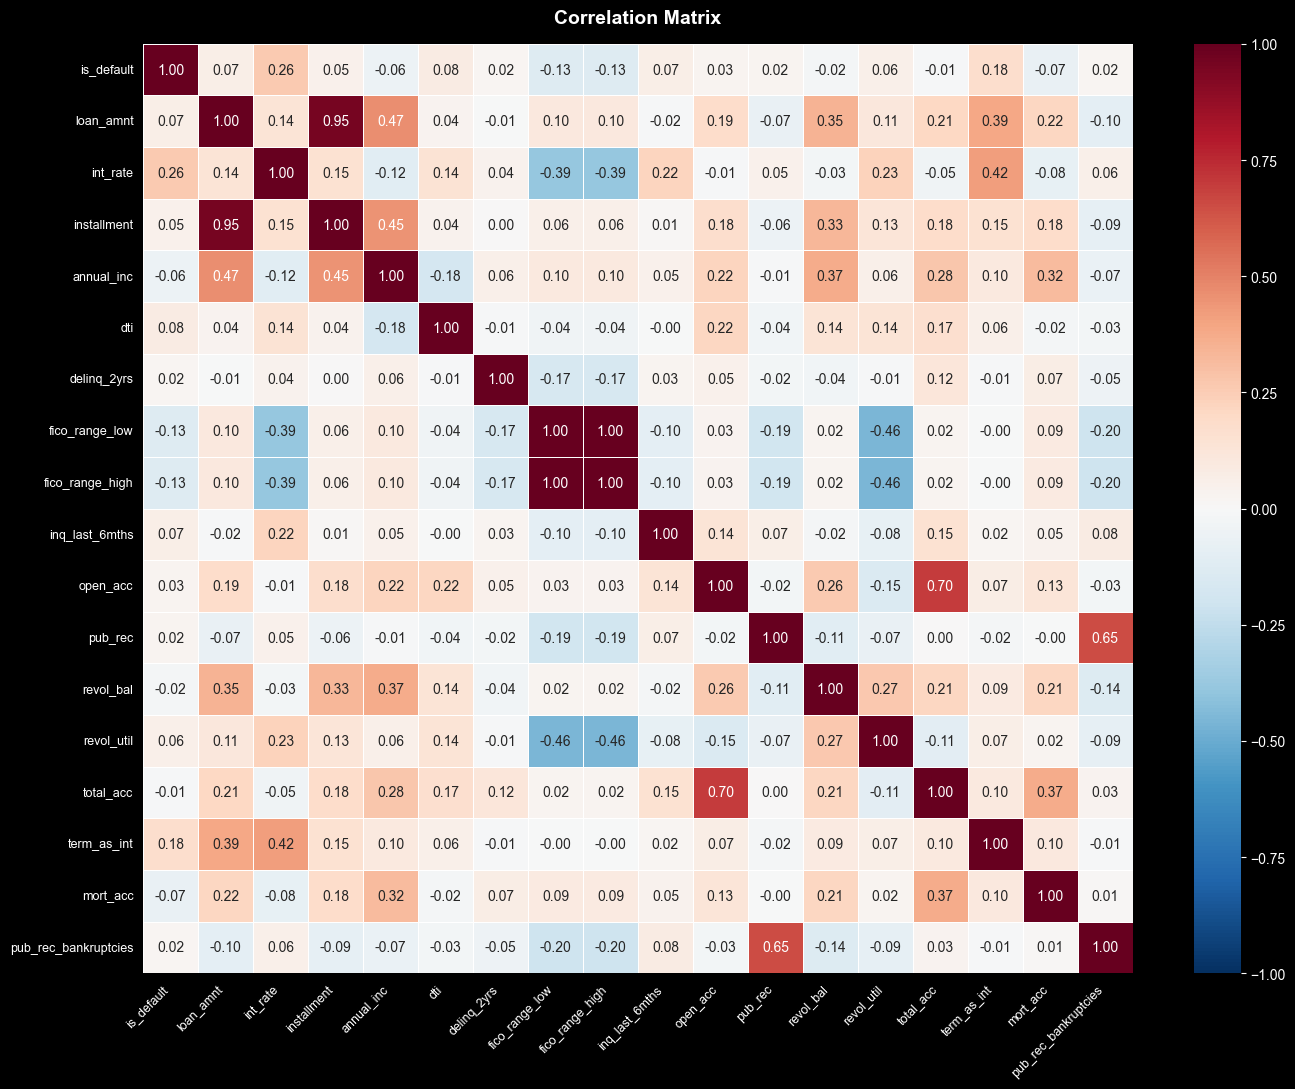

In [202]:
corr_cols = [
    'is_default', 'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'term_as_int', 'mort_acc', 'pub_rec_bankruptcies',
]

corr_matrix = df_resolved[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)

ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [198]:
df_pruned.sample()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,is_inactive,issue_d_dt,term_as_int
1185178,28633167,11200.0,11200.0,11200.0,60 months,18.24,285.88,D,D5,Senior Sales Associate,...,29843.0,27630.0,10200.0,17343.0,N,Cash,N,0,2014-10-01,60.0
